## Question 1

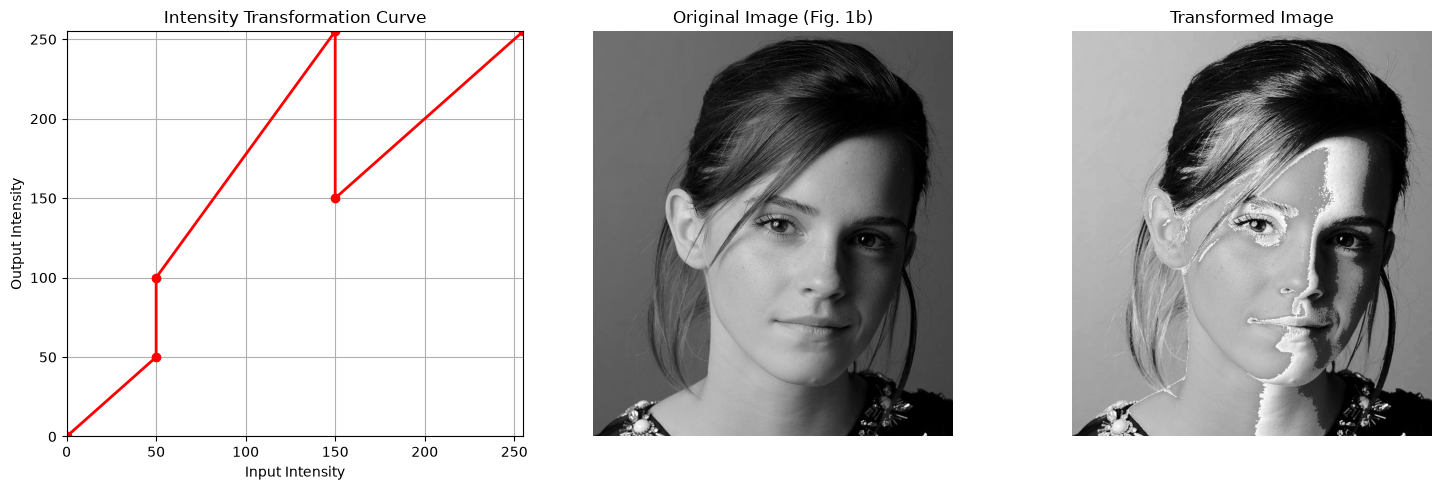

In [86]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
def intensity_transform(im, breakpoints):
    xp = breakpoints[:, 0]
    fp = breakpoints[:, 1]
    transformed_im = np.interp(im, xp, fp).astype(np.uint8)
    return transformed_im
im = cv.imread('images/q1.jpeg', cv.IMREAD_GRAYSCALE)
breakpoints = np.array([
    [0, 0],
    [50, 50],
    [50, 100],
    [150, 255],
    [150, 150],
    [255, 255]
])
transformed_im = intensity_transform(im, breakpoints)
fig = plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(breakpoints[:, 0], breakpoints[:, 1], 'r-o', linewidth=2, markersize=6)
plt.title('Intensity Transformation Curve')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid(True)
plt.subplot(1, 3, 2)
plt.imshow(im, cmap='gray', vmin=0, vmax=255)
plt.title('Original Image (Fig. 1b)')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(transformed_im, cmap='gray', vmin=0, vmax=255)
plt.title('Transformed Image')
plt.axis('off')
plt.tight_layout()
plt.show()

### After Experimenting with different break points

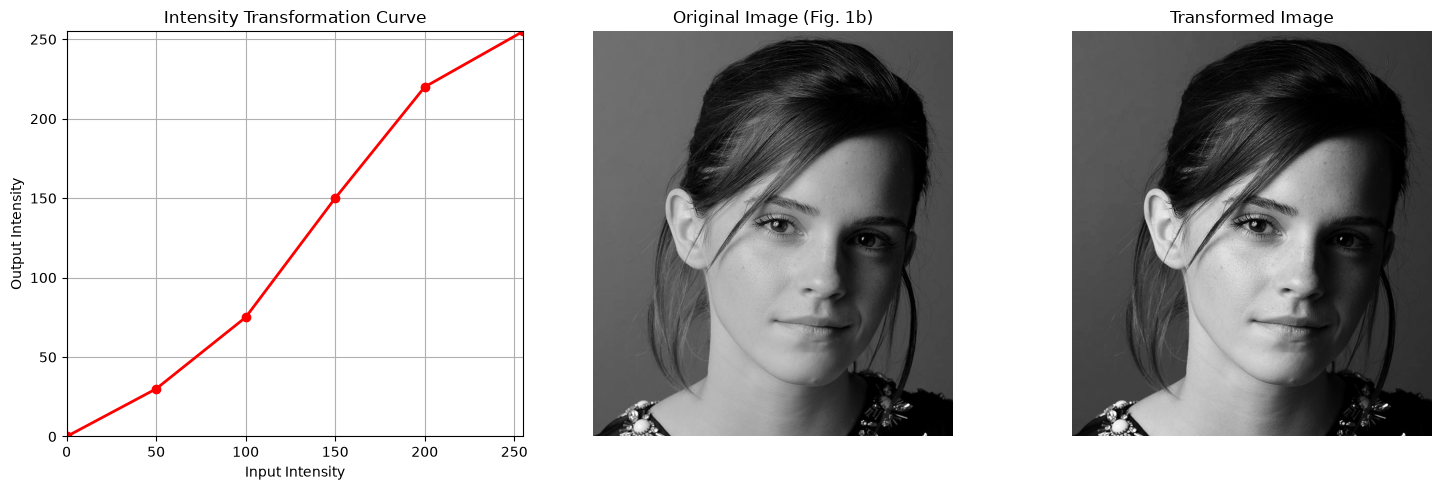

In [87]:
breakpoints = np.array([
    [0, 0],
    [50, 30],
    [100, 75],
    [150, 150],
    [200, 220],
    [255, 255]
])
transformed_im = intensity_transform(im, breakpoints)
fig = plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(breakpoints[:, 0], breakpoints[:, 1], 'r-o', linewidth=2, markersize=6)
plt.title('Intensity Transformation Curve')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid(True)
plt.subplot(1, 3, 2)
plt.imshow(im, cmap='gray', vmin=0, vmax=255)
plt.title('Original Image (Fig. 1b)')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(transformed_im, cmap='gray', vmin=0, vmax=255)
plt.title('Transformed Image')
plt.axis('off')
plt.tight_layout()
plt.show()

## Question 2

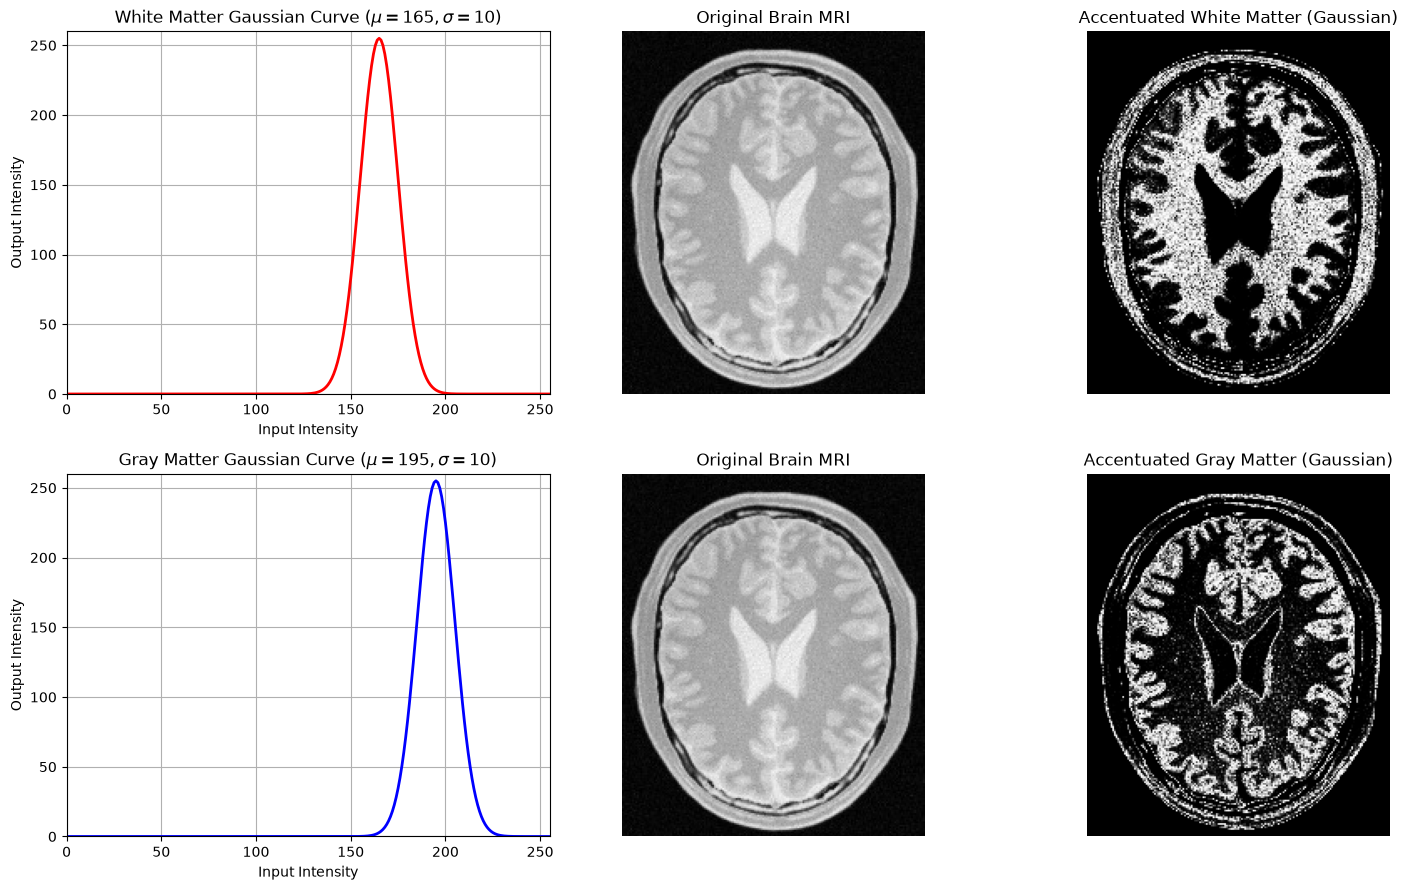

In [88]:
def gaussian_intensity_transform(im, mu, sigma):
    x = im.astype(np.float32)
    transformed = 255.0 * np.exp(-((x - mu)**2) / (2.0 * (sigma**2)))
    return np.clip(transformed, 0, 255).astype(np.uint8)
brain_im = cv.imread('images/q2.jpeg', cv.IMREAD_GRAYSCALE)
mu_wm, sigma_wm = 165.0, 10.0
wm_gaussian = gaussian_intensity_transform(brain_im, mu_wm, sigma_wm)
mu_gm, sigma_gm = 195.0, 10.0
gm_gaussian = gaussian_intensity_transform(brain_im, mu_gm, sigma_gm)
x_vals = np.arange(0, 256)
curve_wm = 255.0 * np.exp(-((x_vals - mu_wm)**2) / (2.0 * (sigma_wm**2)))
curve_gm = 255.0 * np.exp(-((x_vals - mu_gm)**2) / (2.0 * (sigma_gm**2)))
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes[0, 0].plot(x_vals, curve_wm, 'r-', linewidth=2)
axes[0, 0].set_title(rf'White Matter Gaussian Curve ($\mu={int(mu_wm)}, \sigma={int(sigma_wm)}$)')
axes[0, 0].set_xlabel('Input Intensity'); axes[0, 0].set_ylabel('Output Intensity')
axes[0, 0].set_xlim([0, 255]); axes[0, 0].set_ylim([0, 260])
axes[0, 0].grid(True)
axes[0, 1].imshow(brain_im, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Original Brain MRI')
axes[0, 1].axis('off')
axes[0, 2].imshow(wm_gaussian, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title('Accentuated White Matter (Gaussian)')
axes[0, 2].axis('off')
axes[1, 0].plot(x_vals, curve_gm, 'b-', linewidth=2)
axes[1, 0].set_title(rf'Gray Matter Gaussian Curve ($\mu={int(mu_gm)}, \sigma={int(sigma_gm)}$)')
axes[1, 0].set_xlabel('Input Intensity'); axes[1, 0].set_ylabel('Output Intensity')
axes[1, 0].set_xlim([0, 255]); axes[1, 0].set_ylim([0, 260])
axes[1, 0].grid(True)
axes[1, 1].imshow(brain_im, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('Original Brain MRI')
axes[1, 1].axis('off')
axes[1, 2].imshow(gm_gaussian, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title('Accentuated Gray Matter (Gaussian)')
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

## Question 3

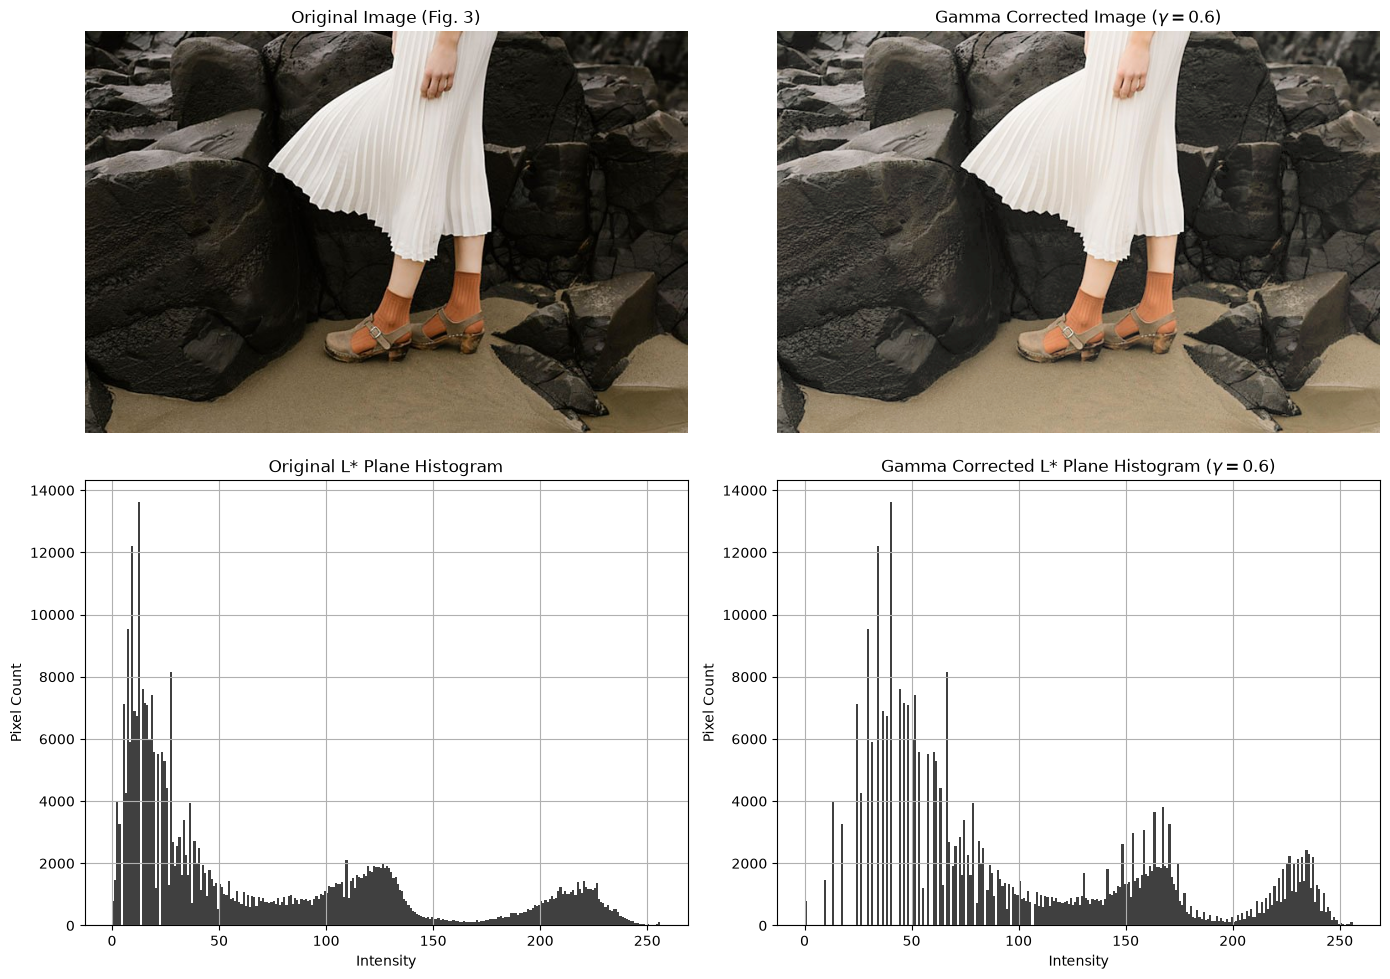

Stated Gamma Value: gamma = 0.6


In [89]:
img_bgr = cv.imread('images/fig3.jpeg')
img_lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)
L_plane, a_plane, b_plane = cv.split(img_lab)
gamma = 0.6
L_normalized = L_plane.astype(np.float32) / 255.0
L_corrected_norm = np.power(L_normalized, gamma)
L_corrected = np.clip(L_corrected_norm * 255.0, 0, 255).astype(np.uint8)
lab_corrected = cv.merge([L_corrected, a_plane, b_plane])
img_corrected_bgr = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)
img_rgb_orig = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_rgb_corr = cv.cvtColor(img_corrected_bgr, cv.COLOR_BGR2RGB)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].imshow(img_rgb_orig)
axes[0, 0].set_title("Original Image (Fig. 3)")
axes[0, 0].axis('off')
axes[0, 1].imshow(img_rgb_corr)
axes[0, 1].set_title(rf"Gamma Corrected Image ($\gamma = {gamma}$)")
axes[0, 1].axis('off')
axes[1, 0].hist(L_plane.ravel(), bins=256, range=[0, 256], color='black', alpha=0.75)
axes[1, 0].set_title("Original L* Plane Histogram")
axes[1, 0].set_xlabel("Intensity")
axes[1, 0].set_ylabel("Pixel Count")
axes[1, 0].grid(True)
axes[1, 1].hist(L_corrected.ravel(), bins=256, range=[0, 256], color='black', alpha=0.75)
axes[1, 1].set_title(rf"Gamma Corrected L* Plane Histogram ($\gamma = {gamma}$)")
axes[1, 1].set_xlabel("Intensity")
axes[1, 1].set_ylabel("Pixel Count")
axes[1, 1].grid(True)
plt.tight_layout()
plt.show()
print(f"Stated Gamma Value: gamma = {gamma}")

## Question 4

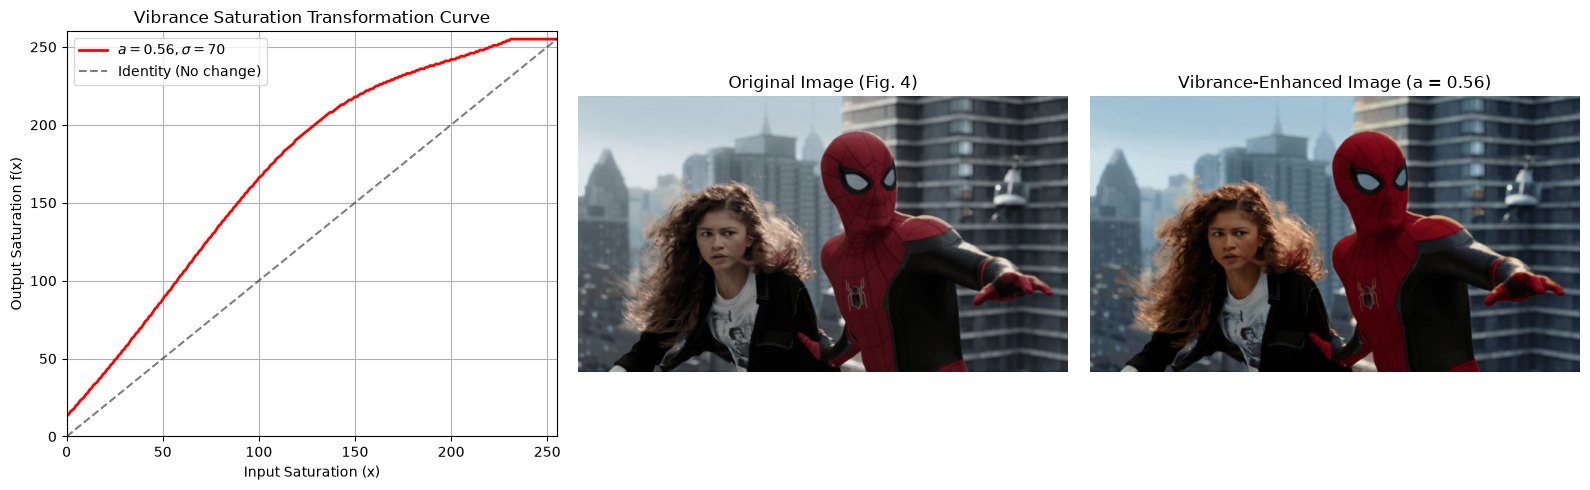

Reported value of a: 0.56


In [90]:
def vibrance_transform(x, a, sigma=70.0):
    x_float = x.astype(np.float32)
    boost = a * 128.0 * np.exp(-((x_float - 128.0)**2) / (2.0 * (sigma**2)))
    transformed = np.minimum(x_float + boost, 255.0)
    return transformed.astype(np.uint8)
img_bgr = cv.imread('images/fig4.jpeg')
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
H, S, V = cv.split(img_hsv)
a_value = 0.56
sigma_value = 70.0
S_enhanced = vibrance_transform(S, a=a_value, sigma=sigma_value)
hsv_enhanced = cv.merge([H, S_enhanced, V])
img_enhanced_bgr = cv.cvtColor(hsv_enhanced, cv.COLOR_HSV2BGR)
img_orig_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_enhanced_rgb = cv.cvtColor(img_enhanced_bgr, cv.COLOR_BGR2RGB)
fig = plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
x_vals = np.arange(0, 256, dtype=np.float32)
y_vals = vibrance_transform(x_vals, a=a_value, sigma=sigma_value)
plt.plot(x_vals, y_vals, 'r-', linewidth=2, label=rf'$a = {a_value}, \sigma = {int(sigma_value)}$')
plt.plot([0, 255], [0, 255], 'k--', alpha=0.5, label='Identity (No change)')
plt.title('Vibrance Saturation Transformation Curve')
plt.xlabel('Input Saturation (x)')
plt.ylabel('Output Saturation f(x)')
plt.xlim([0, 255]); plt.ylim([0, 260])
plt.legend(); plt.grid(True)
plt.subplot(1, 3, 2)
plt.imshow(img_orig_rgb)
plt.title('Original Image (Fig. 4)')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(img_enhanced_rgb)
plt.title(f'Vibrance-Enhanced Image (a = {a_value})')
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"Reported value of a: {a_value}")

## Question 5

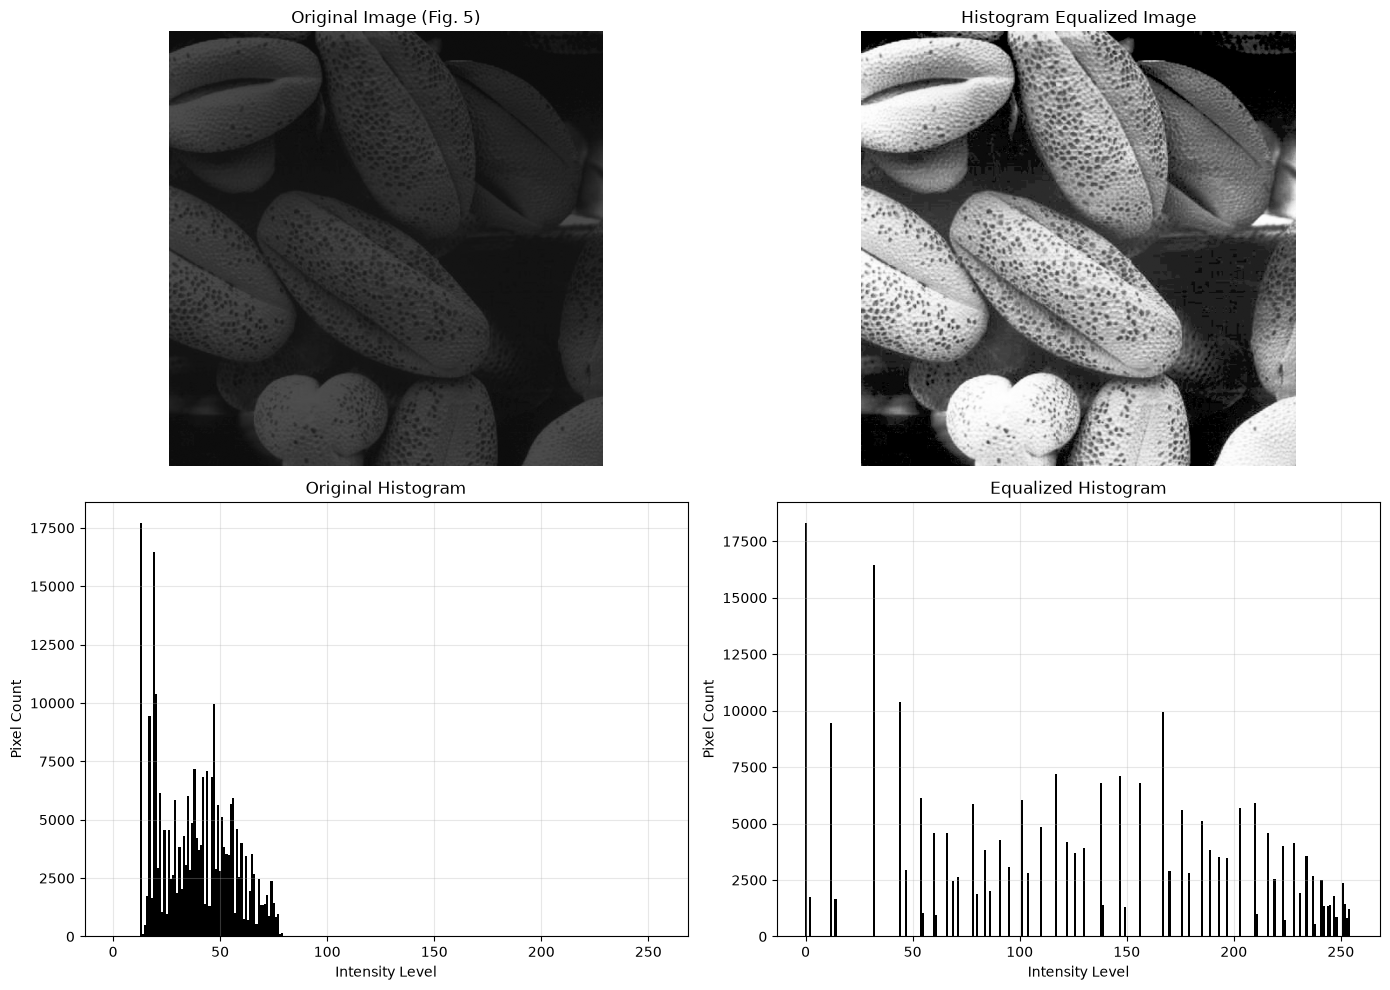

In [91]:
def custom_histogram_equalization(im):
    hist, _ = np.histogram(im.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_masked = np.ma.masked_equal(cdf, 0)
    cdf_normalized = (cdf_masked - cdf_masked.min()) * 255.0 / (cdf_masked.max() - cdf_masked.min())
    lut = np.ma.filled(cdf_normalized, 0).astype(np.uint8)
    im_equalized = lut[im]
    return im_equalized, hist, lut
img_orig = cv.imread('images/shells.tif', cv.IMREAD_GRAYSCALE)
img_eq, hist_orig, lut = custom_histogram_equalization(img_orig)
hist_eq, _ = np.histogram(img_eq.flatten(), 256, [0, 256])
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].imshow(img_orig, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title("Original Image (Fig. 5)")
axes[0, 0].axis('off')
axes[0, 1].imshow(img_eq, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title("Histogram Equalized Image")
axes[0, 1].axis('off')
axes[1, 0].bar(range(256), hist_orig, color='black', width=1.0)
axes[1, 0].set_title("Original Histogram")
axes[1, 0].set_xlabel("Intensity Level")
axes[1, 0].set_ylabel("Pixel Count")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 1].bar(range(256), hist_eq, color='black', width=1.0)
axes[1, 1].set_title("Equalized Histogram")
axes[1, 1].set_xlabel("Intensity Level")
axes[1, 1].set_ylabel("Pixel Count")
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Question 6

Using Threshold: 15


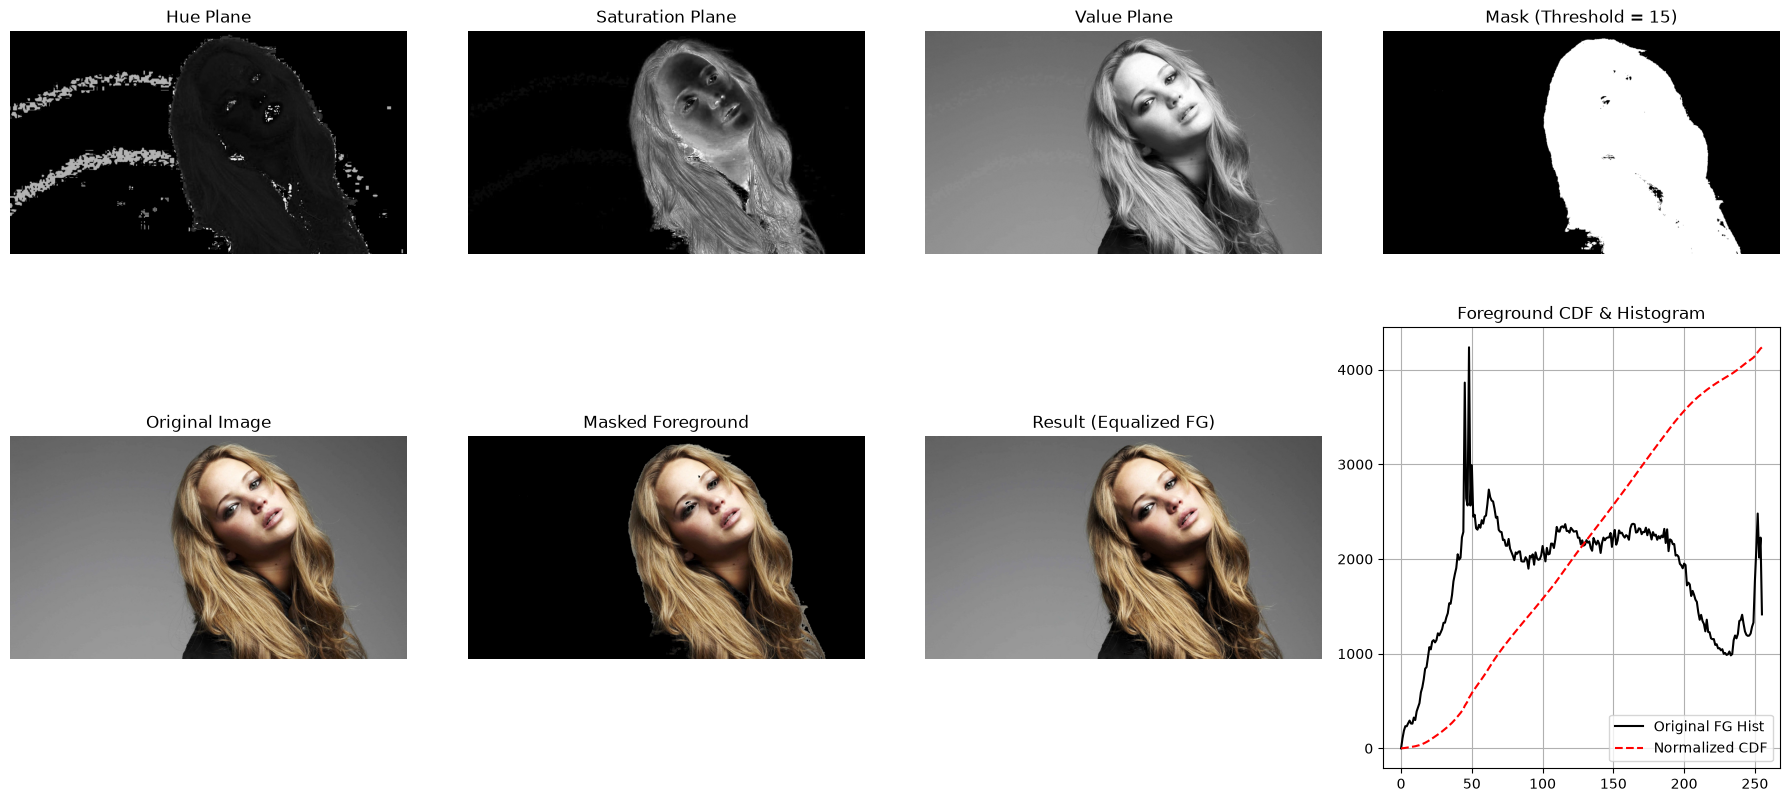

In [92]:
def equalize_foreground(img_path, thresh_val=100):
    img_bgr = cv.imread(img_path)
    img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
    H, S, V = cv.split(img_hsv)
    _, mask = cv.threshold(S, thresh_val, 255, cv.THRESH_BINARY)
    print(f"Using Threshold: {thresh_val}")
    fg_bgr = cv.bitwise_and(img_bgr, img_bgr, mask=mask)
    fg_v = cv.bitwise_and(V, V, mask=mask)
    fg_pixels = fg_v[mask > 0]
    hist_fg, _ = np.histogram(fg_pixels, 256, [0, 256])
    cdf_fg = hist_fg.cumsum()
    cdf_m = np.ma.masked_equal(cdf_fg, 0)
    cdf_normalized = (cdf_m - cdf_m.min()) * 255.0 / (cdf_m.max() - cdf_m.min())
    lut = np.ma.filled(cdf_normalized, 0).astype(np.uint8)
    V_eq = V.copy()
    V_eq[mask > 0] = lut[V[mask > 0]]
    hsv_eq = cv.merge([H, S, V_eq])
    result_bgr = cv.cvtColor(hsv_eq, cv.COLOR_HSV2BGR)
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    fg_rgb = cv.cvtColor(fg_bgr, cv.COLOR_BGR2RGB)
    result_rgb = cv.cvtColor(result_bgr, cv.COLOR_BGR2RGB)
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    axes[0, 0].imshow(H, cmap='gray'); axes[0, 0].set_title("Hue Plane"); axes[0, 0].axis('off')
    axes[0, 1].imshow(S, cmap='gray'); axes[0, 1].set_title("Saturation Plane"); axes[0, 1].axis('off')
    axes[0, 2].imshow(V, cmap='gray'); axes[0, 2].set_title("Value Plane"); axes[0, 2].axis('off')
    axes[0, 3].imshow(mask, cmap='gray'); axes[0, 3].set_title(f"Mask (Threshold = {thresh_val})"); axes[0, 3].axis('off')
    axes[1, 0].imshow(img_rgb); axes[1, 0].set_title("Original Image"); axes[1, 0].axis('off')
    axes[1, 1].imshow(fg_rgb); axes[1, 1].set_title("Masked Foreground"); axes[1, 1].axis('off')
    axes[1, 2].imshow(result_rgb); axes[1, 2].set_title("Result (Equalized FG)"); axes[1, 2].axis('off')
    axes[1, 3].plot(hist_fg, color='black', label='Original FG Hist')
    axes[1, 3].plot(cdf_fg * (hist_fg.max() / cdf_fg.max()), color='red', linestyle='--', label='Normalized CDF')
    axes[1, 3].set_title("Foreground CDF & Histogram")
    axes[1, 3].legend(); axes[1, 3].grid(True)
    plt.tight_layout()
    plt.show()
equalize_foreground('images/fig6.jpeg', thresh_val=15)

## Question 7

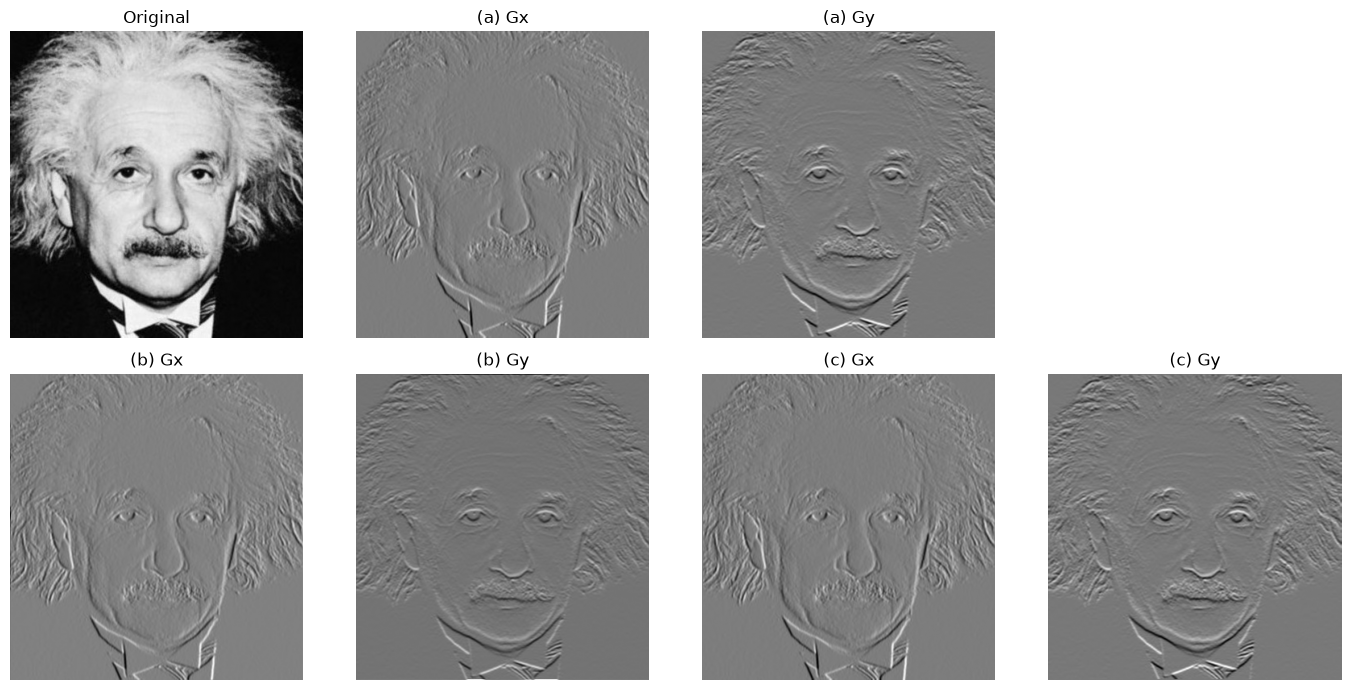

In [93]:
img = cv.imread("images/fig7.jpeg", cv.IMREAD_GRAYSCALE)
Kx = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=np.float32)
Ky = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)
Gx_a = cv.filter2D(img, cv.CV_32F, Kx)
Gy_a = cv.filter2D(img, cv.CV_32F, Ky)
def my_filter2D(image, kernel):
    rows, cols = image.shape
    krows, kcols = kernel.shape
    pad_y = krows // 2
    pad_x = kcols // 2
    padded = np.pad(
        image,
        ((pad_y, pad_y), (pad_x, pad_x)),
        mode='constant',
        constant_values=0
    )
    output = np.zeros((rows, cols), dtype=np.float32)
    for i in range(rows):
        for j in range(cols):
            region = padded[i:i+krows, j:j+kcols]
            output[i, j] = np.sum(region * kernel)

    return output
Gx_b = my_filter2D(img, Kx)
Gy_b = my_filter2D(img, Ky)
vertical_kernel = np.array([
    [1],
    [2],
    [1]
], dtype=np.float32)
horizontal_kernel = np.array([
    [1, 0, -1]
], dtype=np.float32)
temp_x = cv.filter2D(img, cv.CV_32F, vertical_kernel)
Gx_c = cv.filter2D(temp_x, cv.CV_32F, horizontal_kernel)
horizontal_smoothing = np.array([
    [1, 2, 1]
], dtype=np.float32)
vertical_derivative = np.array([
    [1],
    [0],
    [-1]
], dtype=np.float32)
temp_y = cv.filter2D(img, cv.CV_32F, horizontal_smoothing)
Gy_c = cv.filter2D(temp_y, cv.CV_32F, vertical_derivative)
def normalize_image(image):
    return cv.normalize(
        image,
        None,
        0,
        255,
        cv.NORM_MINMAX
    ).astype(np.uint8)
Gx_a = normalize_image(Gx_a)
Gy_a = normalize_image(Gy_a)
Gx_b = normalize_image(Gx_b)
Gy_b = normalize_image(Gy_b)
Gx_c = normalize_image(Gx_c)
Gy_c = normalize_image(Gy_c)
plt.figure(figsize=(14, 7))
plt.subplot(2, 4, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")
plt.subplot(2, 4, 2)
plt.imshow(Gx_a, cmap='gray')
plt.title("(a) Gx")
plt.axis("off")
plt.subplot(2, 4, 3)
plt.imshow(Gy_a, cmap='gray')
plt.title("(a) Gy")
plt.axis("off")
plt.subplot(2, 4, 4)
plt.axis("off")
plt.subplot(2, 4, 5)
plt.imshow(Gx_b, cmap='gray')
plt.title("(b) Gx")
plt.axis("off")
plt.subplot(2, 4, 6)
plt.imshow(Gy_b, cmap='gray')
plt.title("(b) Gy")
plt.axis("off")
plt.subplot(2, 4, 7)
plt.imshow(Gx_c, cmap='gray')
plt.title("(c) Gx")
plt.axis("off")
plt.subplot(2, 4, 8)
plt.imshow(Gy_c, cmap='gray')
plt.title("(c) Gy")
plt.axis("off")
plt.tight_layout()
plt.show()

## Question 8

In [ ]:
def zoom_image(image, s, method="nearest"):
    h, w, c = image.shape
    new_h = int(h * s)
    new_w = int(w * s)
    if method == "nearest":
        zoomed = np.zeros((new_h, new_w, c), dtype=image.dtype)
        for y in range(new_h):
            for x in range(new_w):
                src_y = min(int(round(y / s)), h - 1)
                src_x = min(int(round(x / s)), w - 1)
                zoomed[y, x] = image[src_y, src_x]
    elif method == "bilinear":
        zoomed = np.zeros((new_h, new_w, c), dtype=np.float64)
        for y in range(new_h):
            for x in range(new_w):
                src_y = y / s
                src_x = x / s
                y1 = int(np.floor(src_y))
                x1 = int(np.floor(src_x))
                y2 = min(y1 + 1, h - 1)
                x2 = min(x1 + 1, w - 1)
                dy = src_y - y1
                dx = src_x - x1
                top = (1 - dx) * image[y1, x1] + dx * image[y1, x2]
                bottom = (1 - dx) * image[y2, x1] + dx * image[y2, x2]
                zoomed[y, x] = (1 - dy) * top + dy * bottom
        zoomed = np.clip(zoomed, 0, 255).astype(np.uint8)
    return zoomed
def normalized_ssd(original, reconstructed):
    original = original.astype(np.float64)
    reconstructed = reconstructed.astype(np.float64)
    return np.sum((original - reconstructed) ** 2) / np.sum(original ** 2)
files = [
    ("images/im01.png", "images/im01small.png"),
    ("images/im02.png", "images/im02small.png"),
    ("images/im03.png", "images/im03small.png"),
    ("images/im04.jpg", "images/im04small.jpg")
]
images = []
for i, (original_file, small_file) in enumerate(files):
    original = cv.imread(original_file)
    small = cv.imread(small_file)
    nearest = zoom_image(small, 4, "nearest")
    bilinear = zoom_image(small, 4, "bilinear")
    nearest = nearest[:original.shape[0], :original.shape[1]]
    bilinear = bilinear[:original.shape[0], :original.shape[1]]
    nssd_nearest = normalized_ssd(original, nearest)
    nssd_bilinear = normalized_ssd(original, bilinear)
    images.append((original, small, nearest, bilinear,
                   nssd_nearest, nssd_bilinear))
plt.figure(figsize=(10, 7.5))
for i, (original, small, nearest, bilinear,
        nssd_nearest, nssd_bilinear) in enumerate(images):
    plt.subplot(4, 4, i * 4 + 1)
    plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
    plt.title(f"Original {i + 1}")
    plt.axis("off")
    plt.subplot(4, 4, i * 4 + 2)
    plt.imshow(cv.cvtColor(small, cv.COLOR_BGR2RGB))
    plt.title(f"Small {i + 1}")
    plt.axis("off")
    plt.subplot(4, 4, i * 4 + 3)
    plt.imshow(cv.cvtColor(nearest, cv.COLOR_BGR2RGB))
    plt.title(f"Nearest 4x\nNSSD = {nssd_nearest:.6f}")
    plt.axis("off")
    plt.subplot(4, 4, i * 4 + 4)
    plt.imshow(cv.cvtColor(bilinear, cv.COLOR_BGR2RGB))
    plt.title(f"Bilinear 4x\nNSSD = {nssd_bilinear:.6f}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Question 9

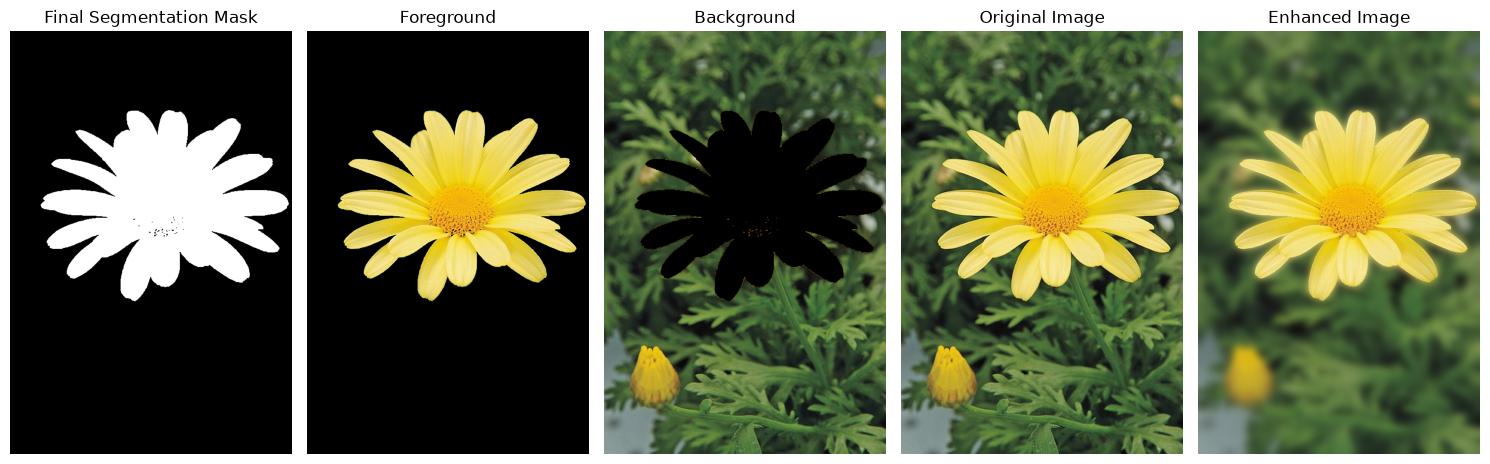

In [ ]:
image = cv.imread("images/q9.jpeg")
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)
h, w = image.shape[:2]
rect = (50, 100, w - 40, h - 350)
mask = np.zeros((h, w), np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)
cv.grabCut(
    image,
    mask,
    rect,
    bgd_model,
    fgd_model,
    10,
    cv.GC_INIT_WITH_RECT
)
final_mask = np.where((mask == cv.GC_FGD) | (mask == cv.GC_PR_FGD), 1, 0).astype(np.uint8)
foreground = image_rgb * final_mask[:, :, np.newaxis]
background = image_rgb * (1 - final_mask[:, :, np.newaxis])
blurred_background = cv.GaussianBlur(image_rgb, (51, 51), 0)
enhanced = (
    image_rgb * final_mask[:, :, np.newaxis]
    + blurred_background * (1 - final_mask[:, :, np.newaxis])
).astype(np.uint8)
plt.figure(figsize=(15, 5))
plt.subplot(1, 5, 1)
plt.imshow(final_mask, cmap="gray")
plt.title("Final Segmentation Mask")
plt.axis("off")
plt.subplot(1, 5, 2)
plt.imshow(foreground)
plt.title("Foreground")
plt.axis("off")
plt.subplot(1, 5, 3)
plt.imshow(background)
plt.title("Background")
plt.axis("off")
plt.subplot(1, 5, 4)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 5, 5)
plt.imshow(enhanced)
plt.title("Enhanced Image")
plt.axis("off")
plt.tight_layout()
plt.show()

(c) The GrabCut mask does not perfectly follow the flower boundary. During Gaussian blurring, pixels around the boundary are averaged with neighboring background pixels. Dark background pixels therefore spread into the region close to the flower edge, producing the dark halo.

## Question 10

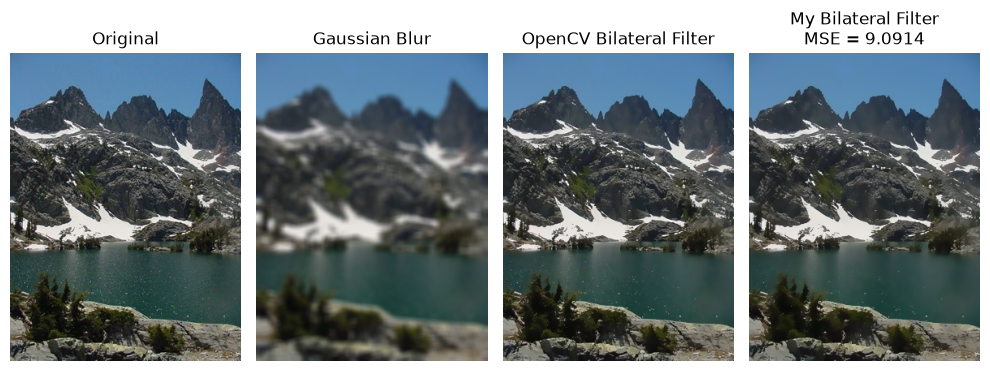

In [ ]:
def bilateral_filter(image, kernel_size, sigma_s, sigma_r):
    radius = kernel_size // 2
    padded = cv.copyMakeBorder(
        image,
        radius,
        radius,
        radius,
        radius,
        cv.BORDER_REFLECT
    )
    output = np.zeros_like(image, dtype=np.float64)
    spatial = np.zeros((kernel_size, kernel_size), dtype=np.float64)
    for y in range(kernel_size):
        for x in range(kernel_size):
            dy = y - radius
            dx = x - radius
            spatial[y, x] = np.exp(
                -(dx**2 + dy**2) / (2 * sigma_s**2)
            )
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            center = padded[y + radius, x + radius].astype(np.float64)
            weighted_sum = np.zeros(3, dtype=np.float64)
            weight_total = 0.0
            for ky in range(kernel_size):
                for kx in range(kernel_size):
                    pixel = padded[
                        y + ky,
                        x + kx
                    ].astype(np.float64)
                    difference = pixel - center
                    range_weight = np.exp(
                        -np.sum(difference**2)
                        / (2 * sigma_r**2)
                    )
                    weight = spatial[ky, kx] * range_weight
                    weighted_sum += weight * pixel
                    weight_total += weight
            output[y, x] = weighted_sum / weight_total
    return np.clip(output, 0, 255).astype(np.uint8)
def mse(image1, image2):
    image1 = image1.astype(np.float64)
    image2 = image2.astype(np.float64)
    return np.mean((image1 - image2) ** 2)
image = cv.imread("images/q10.jpeg")
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)
kernel_size = 9
sigma_s = 5
sigma_r = 30
gaussian = cv.GaussianBlur(
    image,
    (kernel_size, kernel_size),
    sigma_s
)
opencv_bilateral = cv.bilateralFilter(
    image,
    kernel_size,
    sigma_r,
    sigma_s
)
my_bilateral = bilateral_filter(
    image,
    kernel_size,
    sigma_s,
    sigma_r
)
mse_value = mse(
    opencv_bilateral,
    my_bilateral
)
gaussian_rgb = cv.cvtColor(
    gaussian,
    cv.COLOR_BGR2RGB
)
opencv_bilateral_rgb = cv.cvtColor(
    opencv_bilateral,
    cv.COLOR_BGR2RGB
)
my_bilateral_rgb = cv.cvtColor(
    my_bilateral,
    cv.COLOR_BGR2RGB
)
plt.figure(figsize=(10, 20))
plt.subplot(1, 4, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")
plt.subplot(1, 4, 2)
plt.imshow(gaussian_rgb)
plt.title("Gaussian Blur")
plt.axis("off")
plt.subplot(1, 4, 3)
plt.imshow(opencv_bilateral_rgb)
plt.title("OpenCV Bilateral Filter")
plt.axis("off")
plt.subplot(1, 4, 4)
plt.imshow(my_bilateral_rgb)
plt.title(f"My Bilateral Filter\nMSE = {mse_value:.4f}")
plt.axis("off")
plt.tight_layout()
plt.show()